# Spatial decay of pairwise spike coordination

Pairwise spike coordination falls off steeply with the distance between the two
electrodes. This notebook measures that fall-off, fits a length constant to it,
and asks whether it depends on what the animal was fixating.

## Why this analysis exists

Within-region pairs are recorded on the **same electrode array**; cross-region
pairs are not. So the observation that within-region pairs are more coordinated
than cross-region pairs is confounded before it starts — a shared reference, a
shared amplifier, or any common noise on an array produces exactly that pattern
with no biology involved. On its own the comparison cannot be interpreted.

Electrode separation breaks the tie, because the two explanations make
**opposite predictions about the same measurement**:

- a shared reference contaminates every pair on an array equally → **flat** with separation
- local circuitry → **decays** with separation

No new data is needed; the discriminating test is already in the pairs we have.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spatial_decay as sd
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_spatial_decay as viz

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

cfg = load_config(str(repo_root / "configs" / "dataset.yaml"))
settings = sd.SpatialDecaySettings(cfg_path=str(repo_root / "configs" / "dataset.yaml"))
FIGURE_DIR = build_analysis_output_dir(cfg, sd.DEFAULT_OUTPUT_SUBDIR) / "spatial_decay"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figs = viz.SpatialDecayPlotSettings(output_dir=FIGURE_DIR)
print("figures ->", FIGURE_DIR)

figures -> /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/spatial_decay


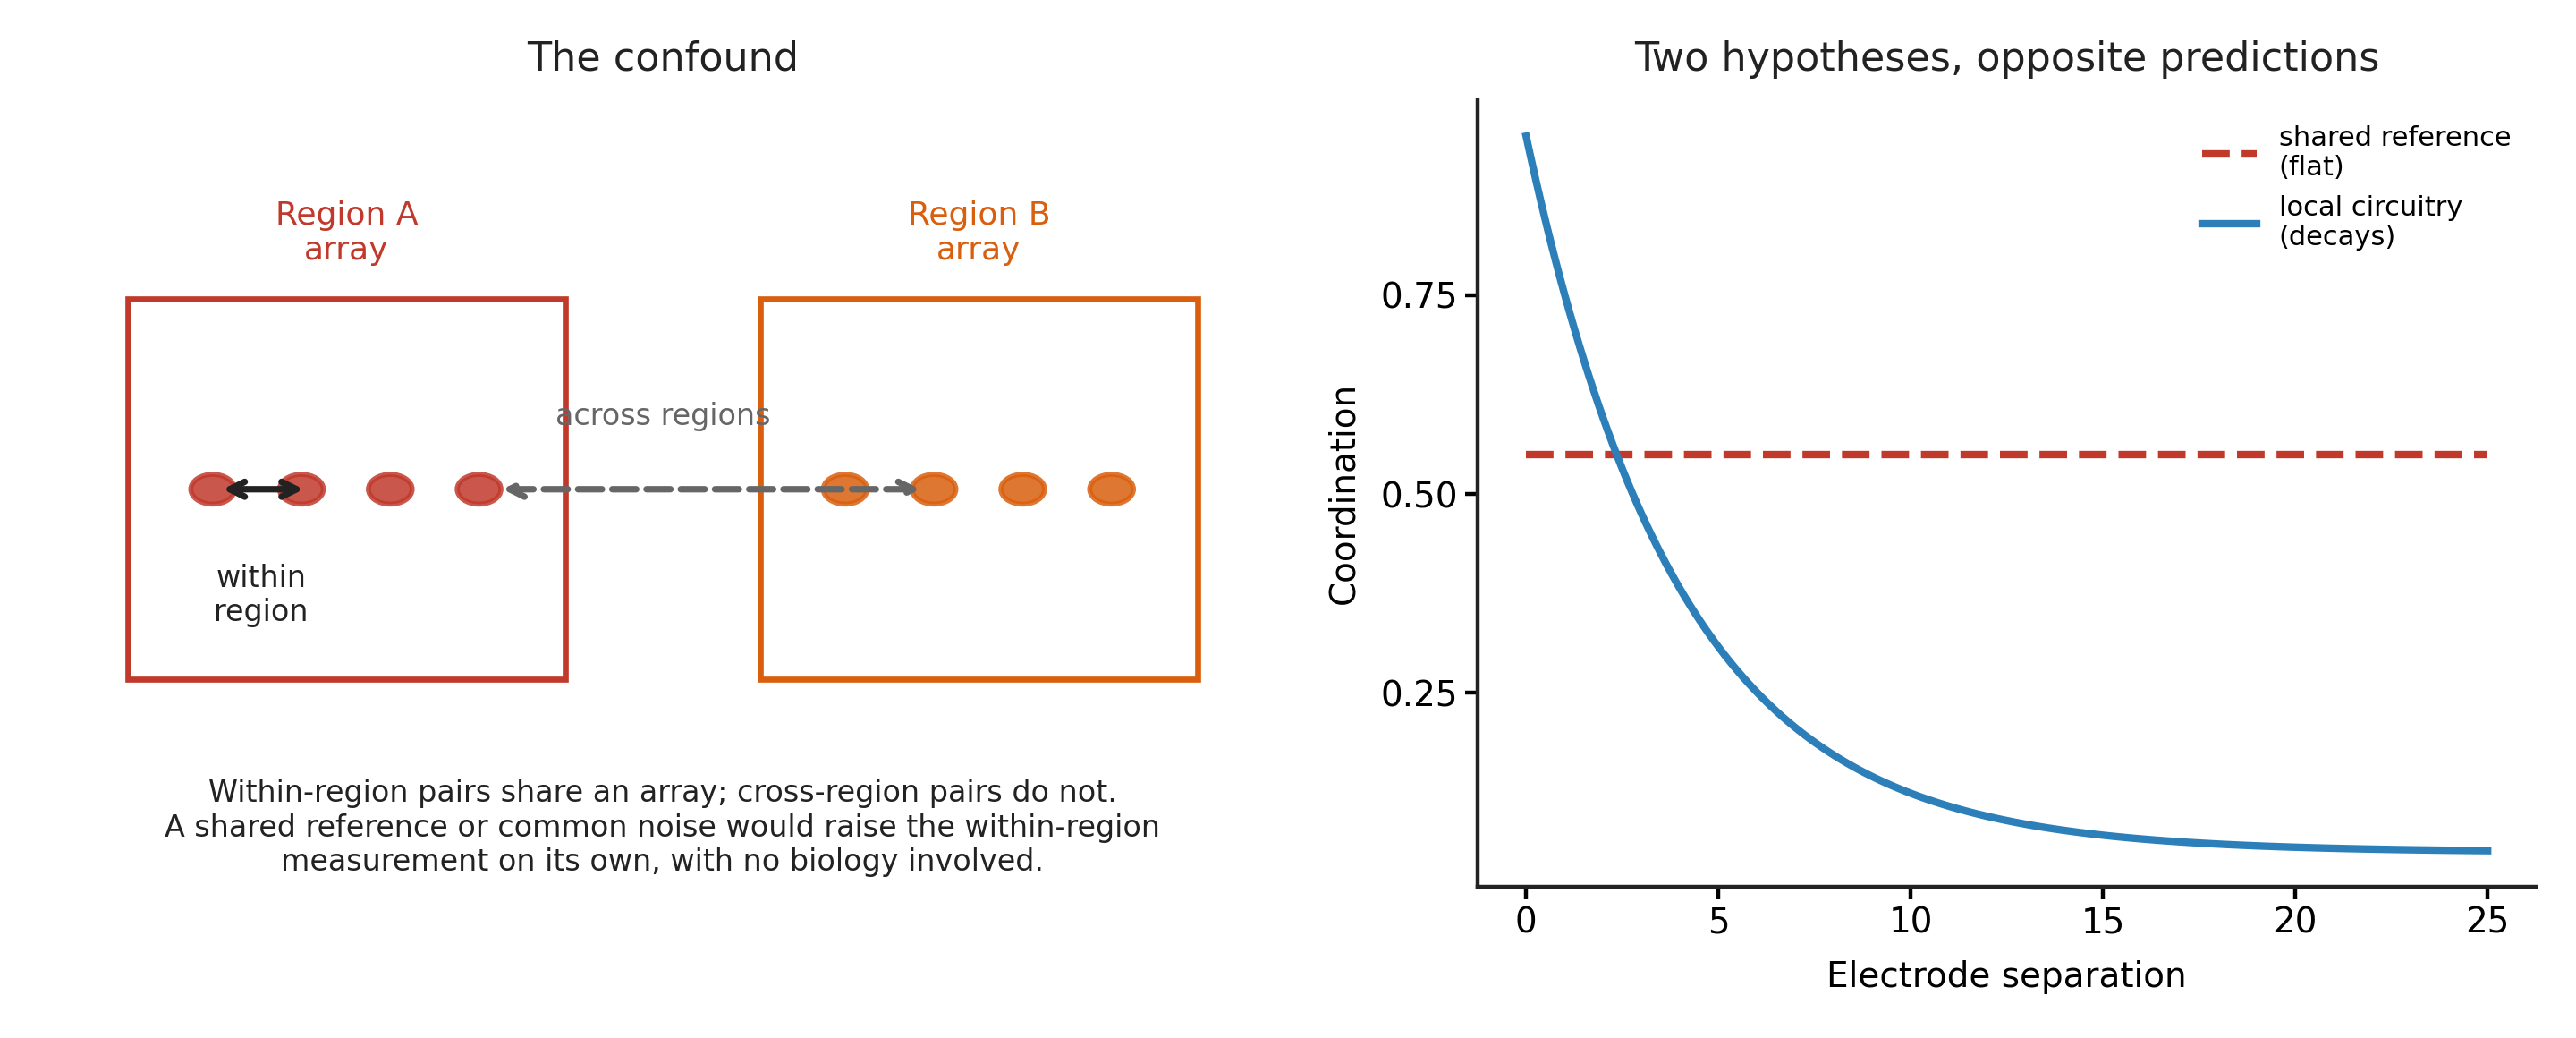

In [2]:
fig, paths = viz.plot_confound_schematic(figs)
display(Image(filename=str(paths["png"])))

## Methods

Every cross-correlation is computed on one fixation's two **unsmoothed 1 ms**
spike trains over the **±500 ms** window around fixation onset, then averaged
across fixations. The null is a **circular shift**: unit B's train is rotated by
at least 50 ms within its own fixation, so each fixation keeps its own spike
counts and slow envelope and only fine temporal alignment is destroyed. Two
cells whose excitability merely rises and falls together across fixations
therefore produce no excess.

The null-corrected correlation is summarised by two numbers per pair, because
they can behave differently: a **sharp peak** (±2 ms) and a **broad shoulder**
(20–100 ms), each after subtracting that pair's own 200–250 ms baseline.

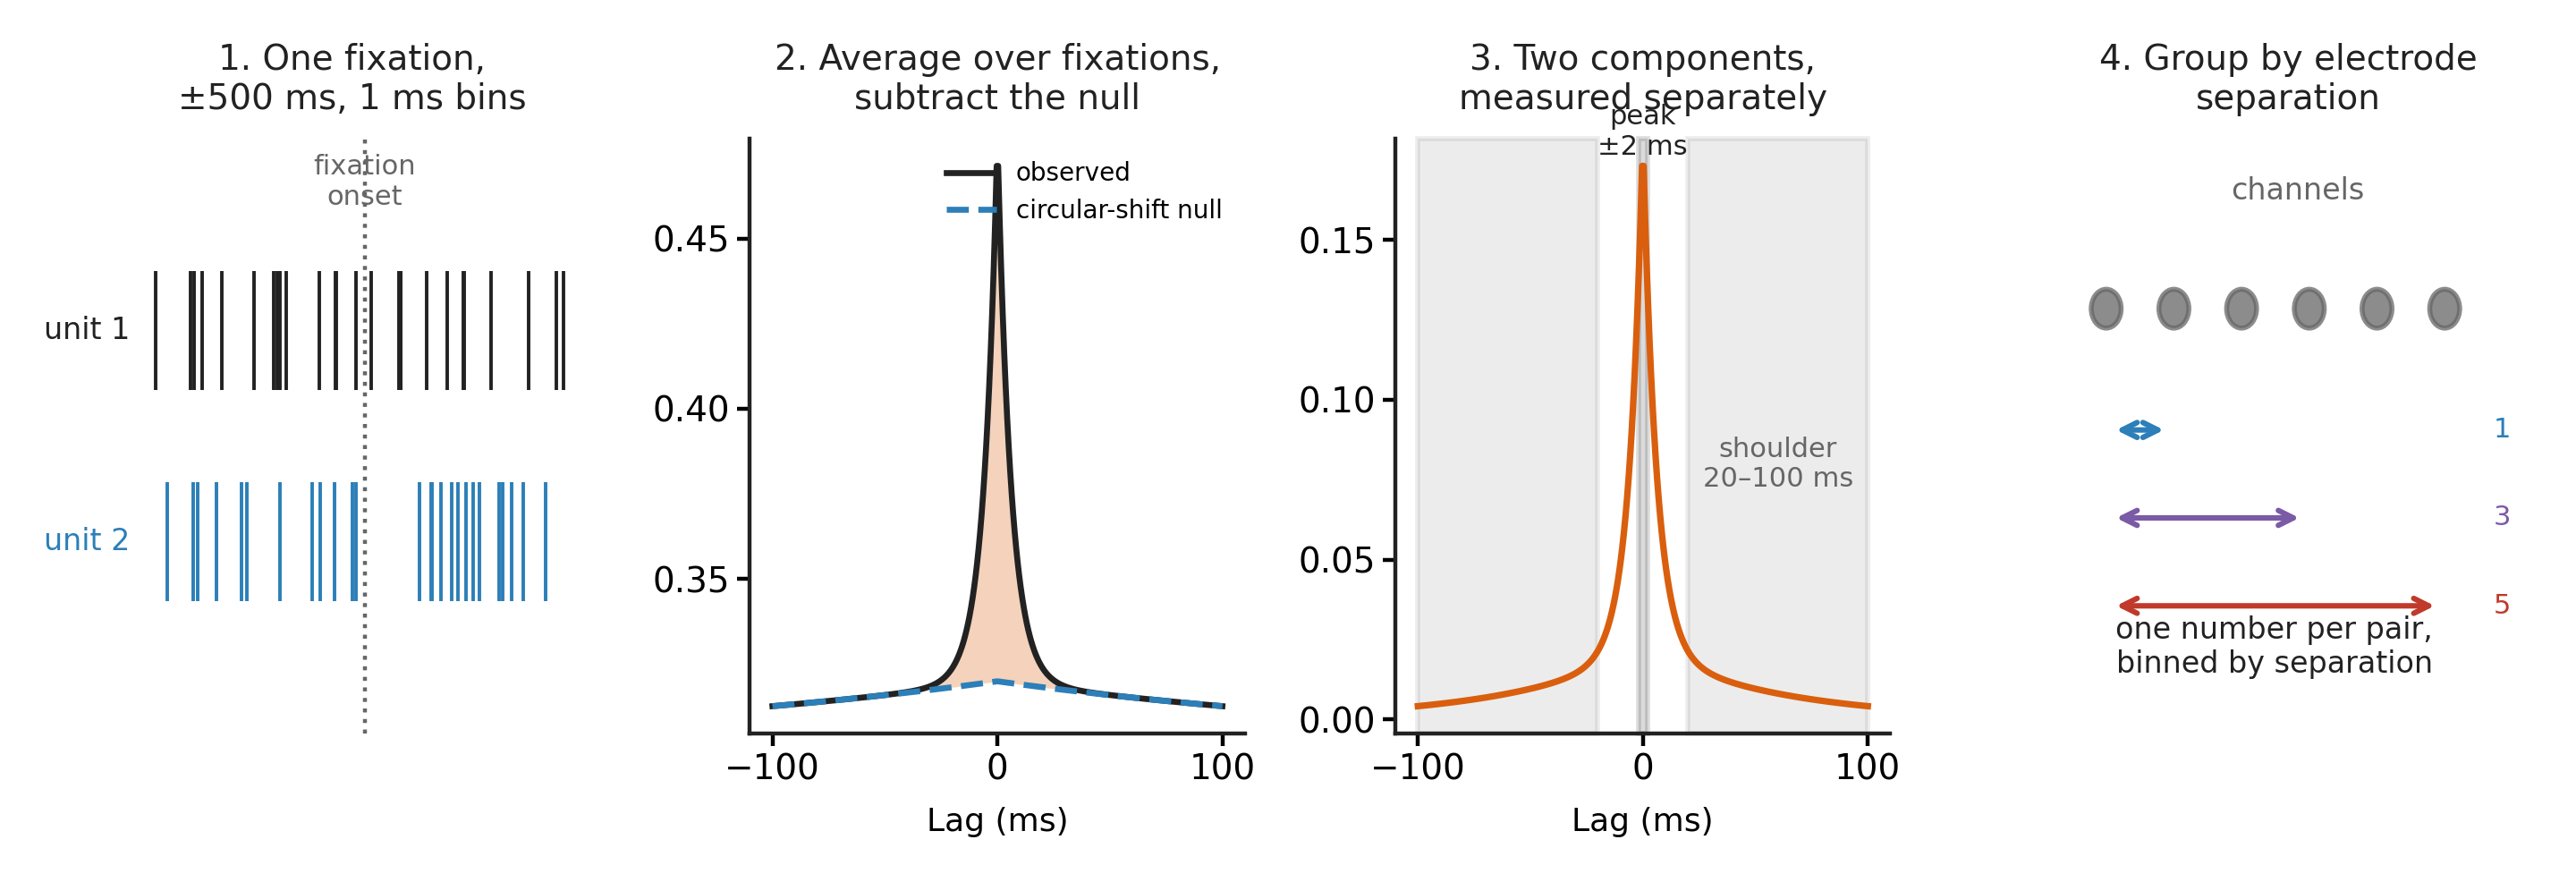

In [3]:
fig, paths = viz.plot_method_schematic(figs)
display(Image(filename=str(paths["png"])))

### The separation measure, and what it is not

Channels are named `SPKnn` and numbered in contiguous blocks per region, so
`|n1 − n2|` is the separation. This is a **proxy** for physical distance, not a
calibrated one: it assumes channel numbering runs in spatial order. A monotone
decay is itself evidence that the numbering tracks something spatial — an
arbitrary permutation of channel labels would destroy it — but that is an
argument, not a calibration. **Check it against the array geometry before
quoting length constants in millimetres.**

Pairs on the *same* channel are excluded and reported separately. They carry a
*negative* zero-lag excess, because a spike sorter cannot assign two spikes to
different units in the same millisecond on one channel. That shadowing is a
property of the sorter, not the tissue — and its appearing with the right sign
is a check that the pipeline measures what it claims.

In [4]:
pairs, dropped = sd.load_pairs_with_separation(settings)
print(f"pairs: {len(pairs):,}   artifact dates removed: {dropped}")
print(f"within region: {(pairs['scope'] == 'within_region').sum():,}   "
      f"across regions: {(pairs['scope'] == 'cross_region').sum():,}   "
      f"same channel: {pairs['same_channel'].sum():,}")

display(sd.build_separation_inventory(pairs))

pairs: 437,605   artifact dates removed: ['09292018']
within region: 241,420   across regions: 196,185   same channel: 8,706


,region,n_pairs,n_same_channel,max_separation,n_1,n_2–3,n_4–7,n_8–15,n_>15
0,bla,106697,5224,15.0,14959,25882,37301,23331,0
1,accg,42348,590,47.0,3815,6369,9651,10697,11226
2,dmpfc,35834,1408,46.0,4002,6452,8433,6174,9365
3,ofc,56541,1484,47.0,5229,9174,14048,12463,14143


## 1. The decay

Each point is the mean null-corrected sharp peak for pairs in that separation
bin, with a bootstrap interval. The curve is a fitted exponential
`A·exp(−d/λ) + c`. The offset `c` is fitted rather than assumed zero: it is
where coordination settles at long range, and any shared-reference contribution
would live there rather than in the amplitude, which keeps the two separable.

The y-axis is logarithmic — the range spans two orders of magnitude across
regions, and a linear axis renders ACCg as a flat line at the bottom.

,region,separation_bin,separation,n_pairs,mean,median,sem,ci_low,ci_high
0,bla,1,1.0,14959,0.03469,0.00500,0.00091,0.03302,0.03653
1,bla,2–3,2.5,25882,0.01914,0.00202,0.00044,0.01829,0.02007
2,bla,4–7,5.5,37301,0.00936,-0.00017,0.00025,0.00885,0.00984
3,bla,8–15,11.5,23331,0.00688,-0.00047,0.00030,0.00629,0.00751
4,accg,1,1.0,3815,0.01396,0.00000,0.00086,0.01239,0.01560
5,accg,2–3,2.5,6369,0.00877,-0.00035,0.00053,0.00778,0.00977
6,accg,4–7,5.5,9651,0.00535,-0.00077,0.00033,0.00469,0.00601
7,accg,8–15,11.5,10697,0.00597,-0.00065,0.00032,0.00533,0.00658
8,accg,>15,24.0,11226,0.00528,-0.00098,0.00029,0.00478,0.00588
9,dmpfc,1,1.0,4002,0.06288,0.01054,0.00252,0.05845,0.06750


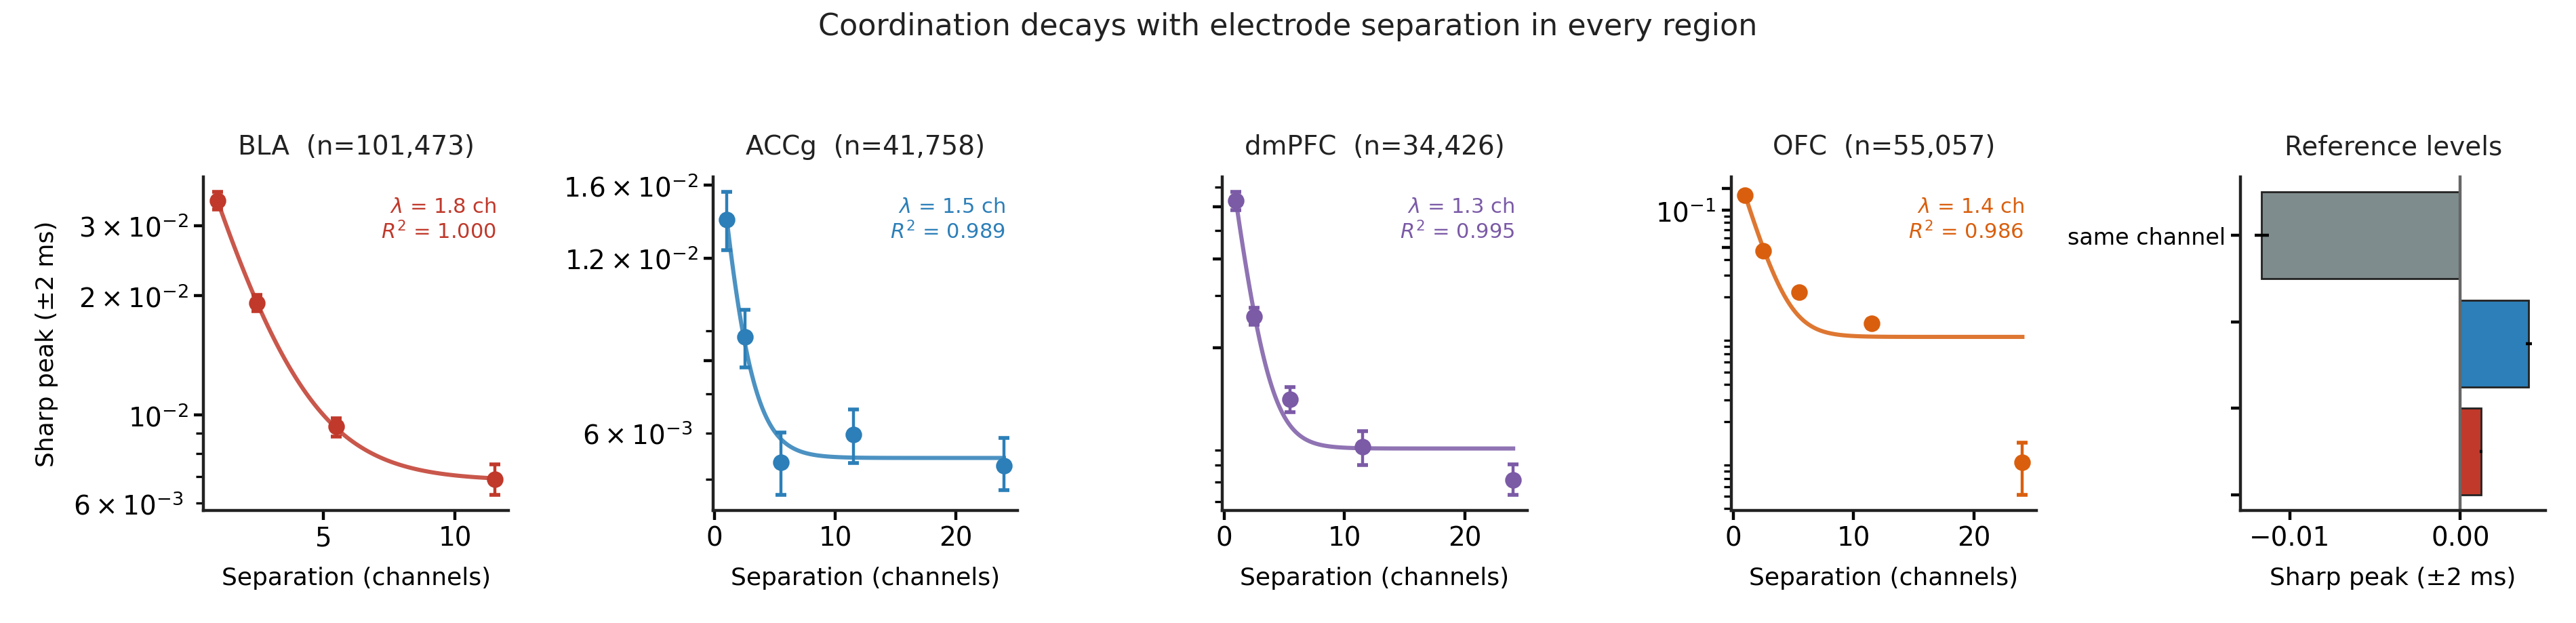

In [5]:
decay = sd.build_decay_table(pairs, settings)
fits = sd.fit_decay_by_group(decay)
references = sd.build_reference_levels(pairs)

display(decay.round(5))
fig, paths = viz.plot_decay_curves(decay, fits, figs, references=references)
display(Image(filename=str(paths["png"])))

### Is it flat, as a shared reference would predict?

A Spearman correlation between separation and the per-bin mean. Flatness is the
artifact hypothesis; a strong negative rank correlation rejects it.

The reference levels below are what the decay should be read against: the
same-channel shadowing floor, the far within-region bin, and the cross-region
level. The far within-region pairs land close to — but still above — cross
region, which is the residual that a same-array offset would explain.

In [6]:
display(sd.test_decay_flatness(decay).round(5))
display(references.round(5))

,region,n_bins,spearman_rho,p_value,nearest_bin_mean,farthest_bin_mean,fold_decay
0,bla,4,-1.0,0.00000,0.03469,NaN,NaN
1,accg,5,-0.9,0.03739,0.01396,0.00528,2.64644
2,dmpfc,5,-1.0,0.00000,0.06288,0.00713,8.81983
3,ofc,5,-1.0,0.00000,0.13200,0.00094,140.93771


,level,n_pairs,mean,sem
0,same channel,8706,-0.01165,0.00042
1,>15 ch apart,34734,0.00401,0.00017
2,cross region,196185,0.00122,0.00008


## 2. How strongly, and how far

Splitting the fit into amplitude and length constant makes the result readable
in one line. Watch which of the two carries the region differences.

,region,amplitude,amplitude_low,amplitude_high,length_constant,length_constant_low,length_constant_high,offset,r_squared,n_bins,total_pairs
0,bla,0.0478,0.0428,0.0532,1.8463,1.6508,2.0756,0.0068,1.0000,4.0,101473
1,accg,0.0168,0.0118,0.0243,1.4922,1.0894,2.0818,0.0054,0.9890,5.0,41758
2,dmpfc,0.1143,0.0949,0.1354,1.3201,1.1577,1.5314,0.0091,0.9950,5.0,34426
3,ofc,0.2554,0.2225,0.2904,1.3508,1.2338,1.4996,0.0096,0.9861,5.0,55057


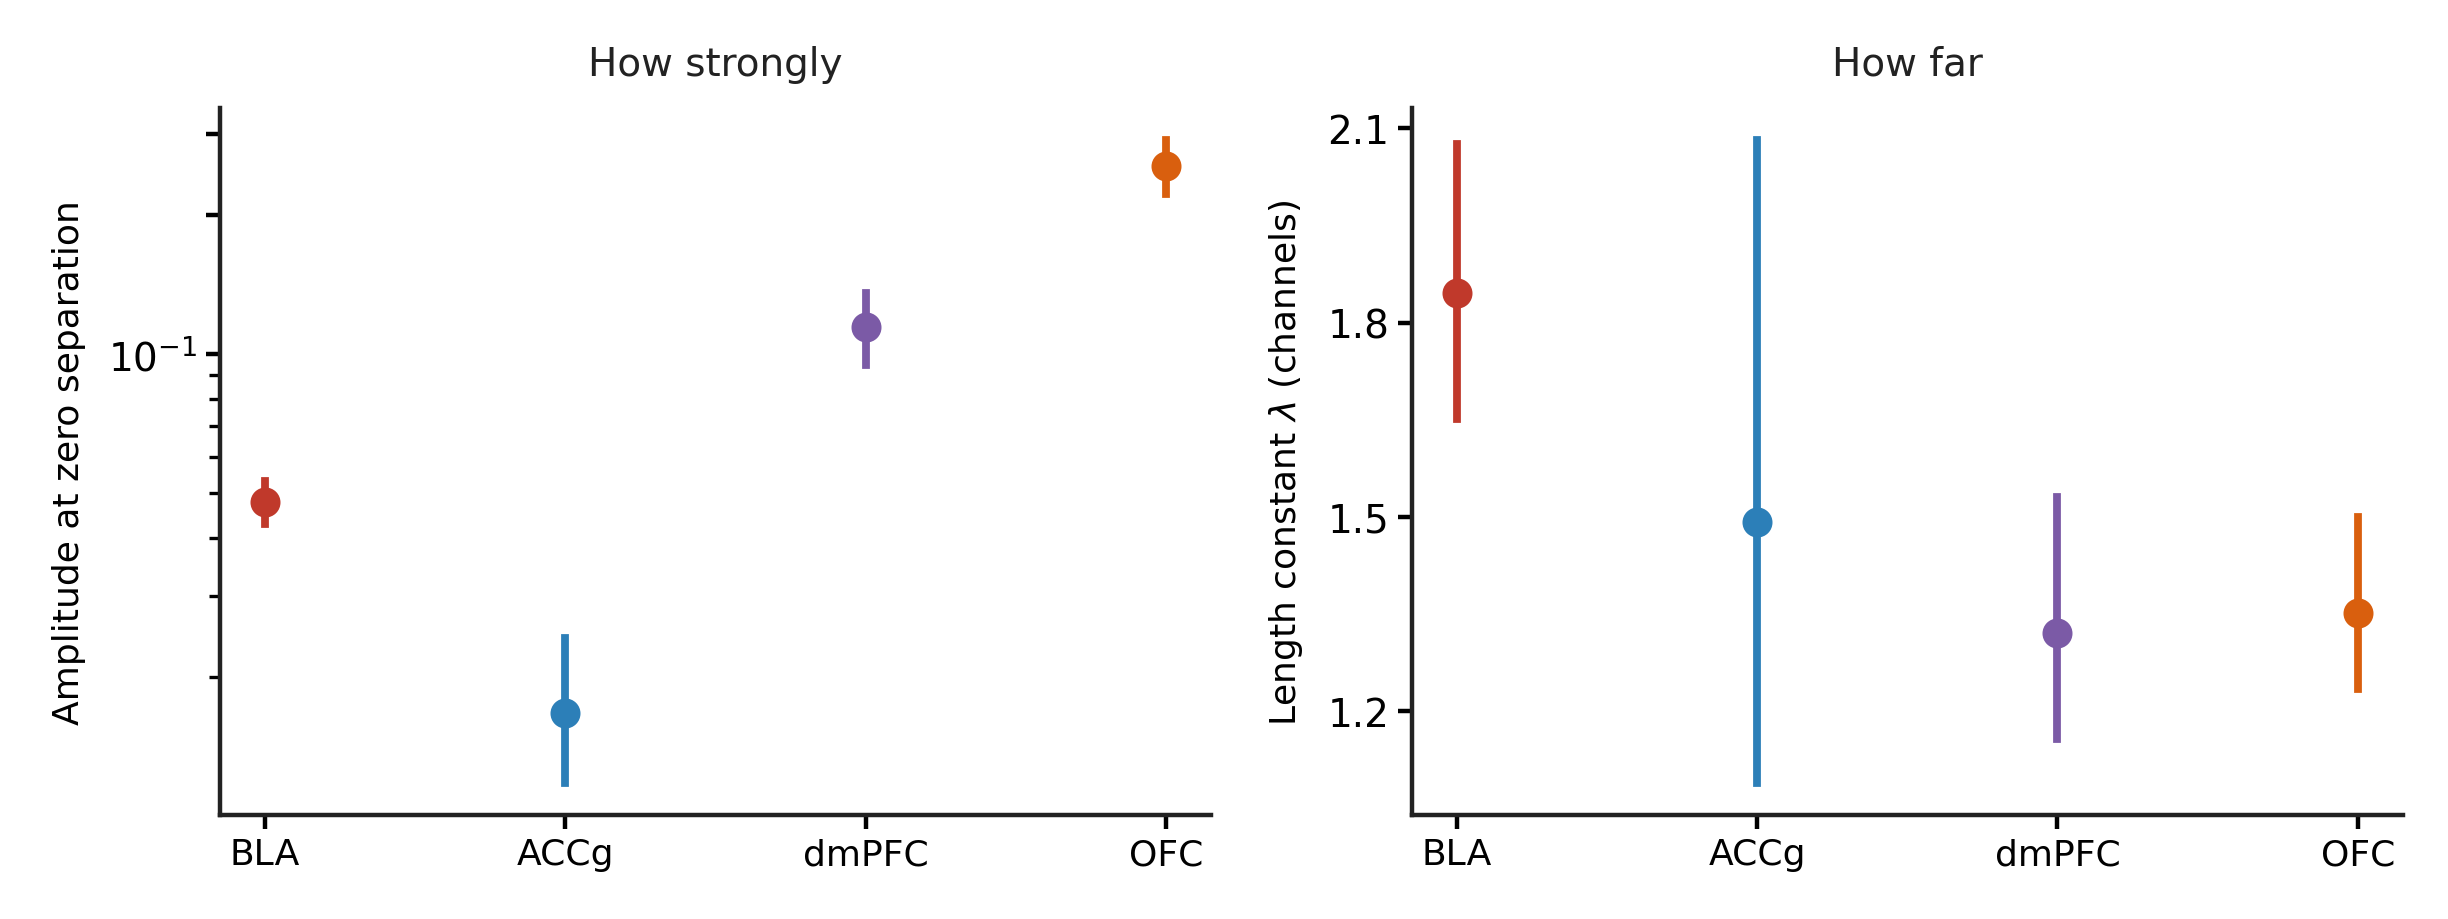

In [7]:
display(fits.round(4))
fig, paths = viz.plot_fit_parameters(fits, figs)
display(Image(filename=str(paths["png"])))

## 3. Is the decay fixation-specific?

The decay could depend on fixation condition in two distinct ways, and they
need separating:

1. the **level** differs by condition at every distance → curves shift vertically → *amplitude* changes
2. the **reach** differs → curves change shape → *length constant* changes

Fitting each condition separately tests both at once. Compare the bootstrap
intervals: overlapping intervals mean the parameter is not distinguishable
between conditions.

,region,condition,amplitude,amplitude_low,amplitude_high,length_constant,length_constant_low,length_constant_high,offset,r_squared,n_bins,total_pairs
0,bla,face_interactive,0.0456,0.0378,0.0546,1.6355,1.3969,1.9534,0.0066,0.9991,4.0,41790
1,bla,face_non_interactive,0.0537,0.0443,0.0646,1.9665,1.6180,2.4232,0.0079,0.9967,4.0,28292
2,bla,object,0.0461,0.0379,0.0561,1.9903,1.5861,2.5369,0.0062,0.9987,4.0,31391
3,accg,face_interactive,0.0153,0.0098,0.0247,1.5558,1.0556,2.4014,0.0050,0.9861,5.0,16834
4,accg,face_non_interactive,0.0189,0.0104,0.0370,1.6929,0.9426,3.3477,0.0032,0.9813,5.0,11919
5,accg,object,0.0176,0.0080,0.2837,1.1573,0.2790,2.4691,0.0081,0.9747,5.0,13005
6,dmpfc,face_interactive,0.1056,0.0788,0.1371,1.3000,1.0809,1.6363,0.0097,0.9899,5.0,13870
7,dmpfc,face_non_interactive,0.1271,0.0921,0.1711,1.2937,1.0374,1.6872,0.0102,0.9986,5.0,10833
8,dmpfc,object,0.1126,0.0788,0.1560,1.3787,1.0645,1.8982,0.0070,0.9927,5.0,9723
9,ofc,face_interactive,0.2431,0.1961,0.2967,1.4471,1.2528,1.7279,0.0094,0.9883,5.0,20362


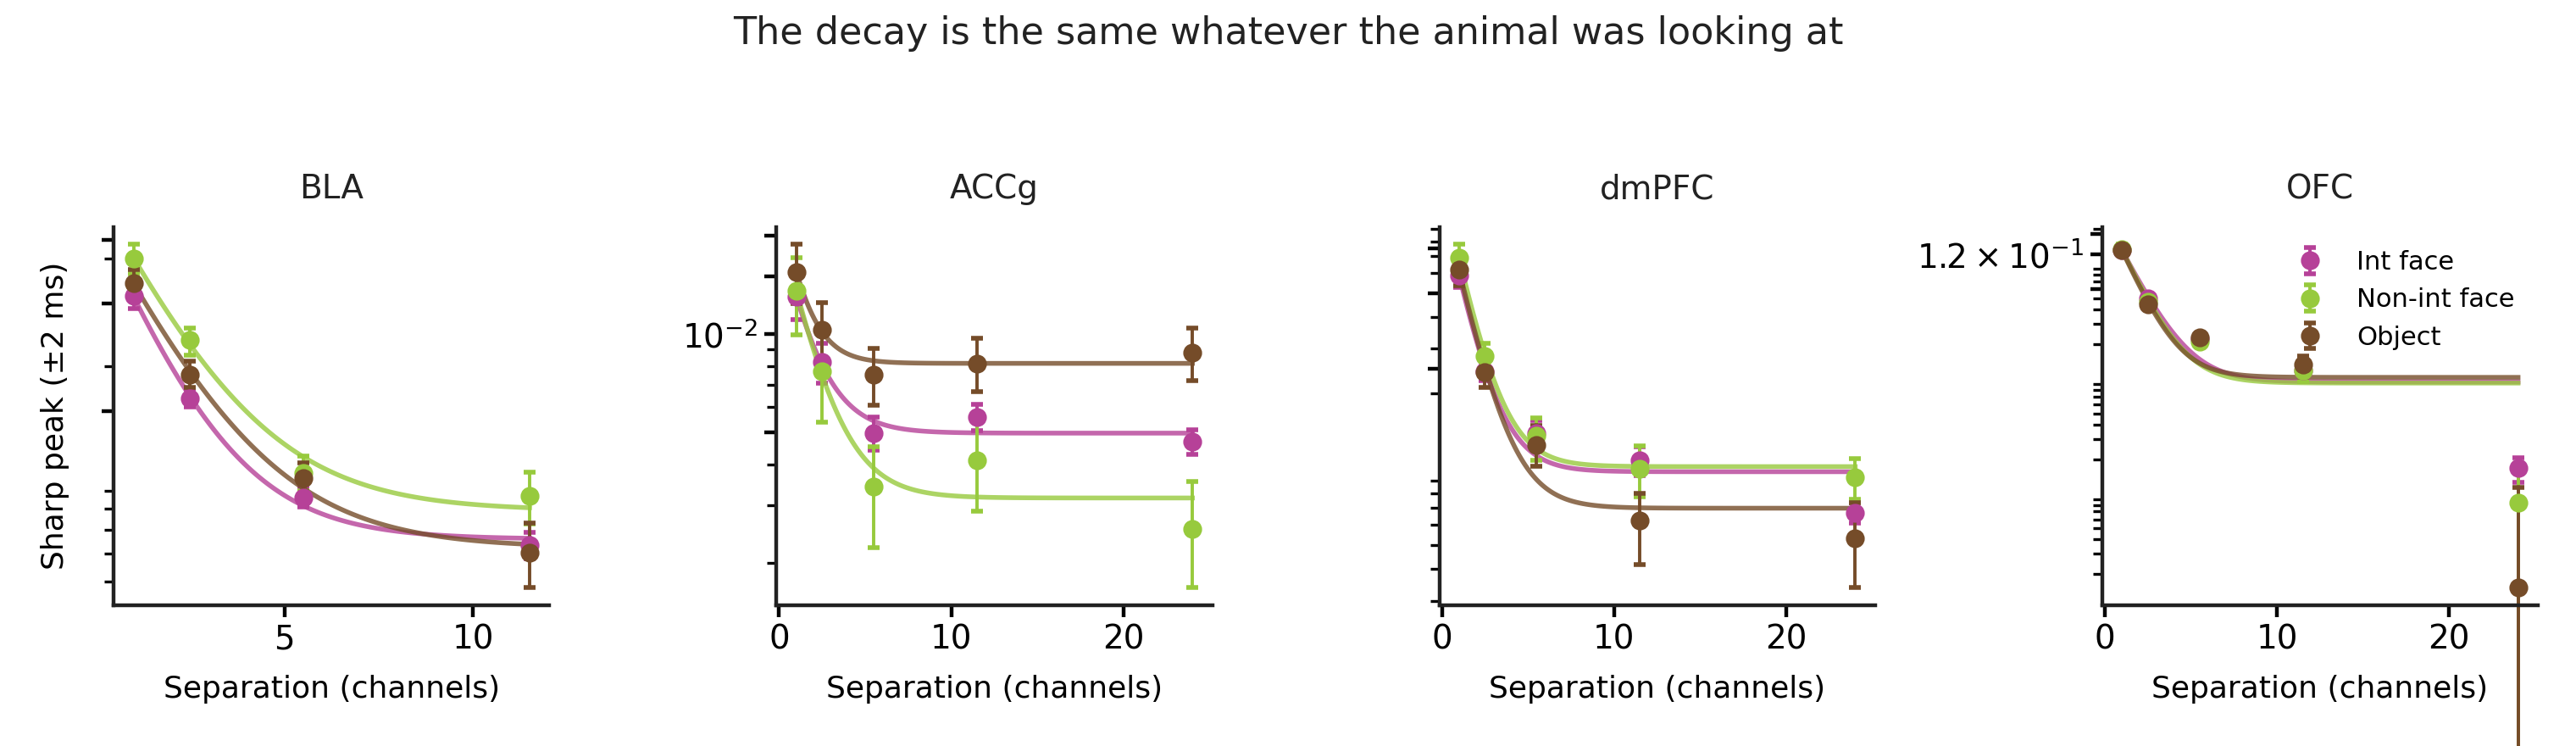

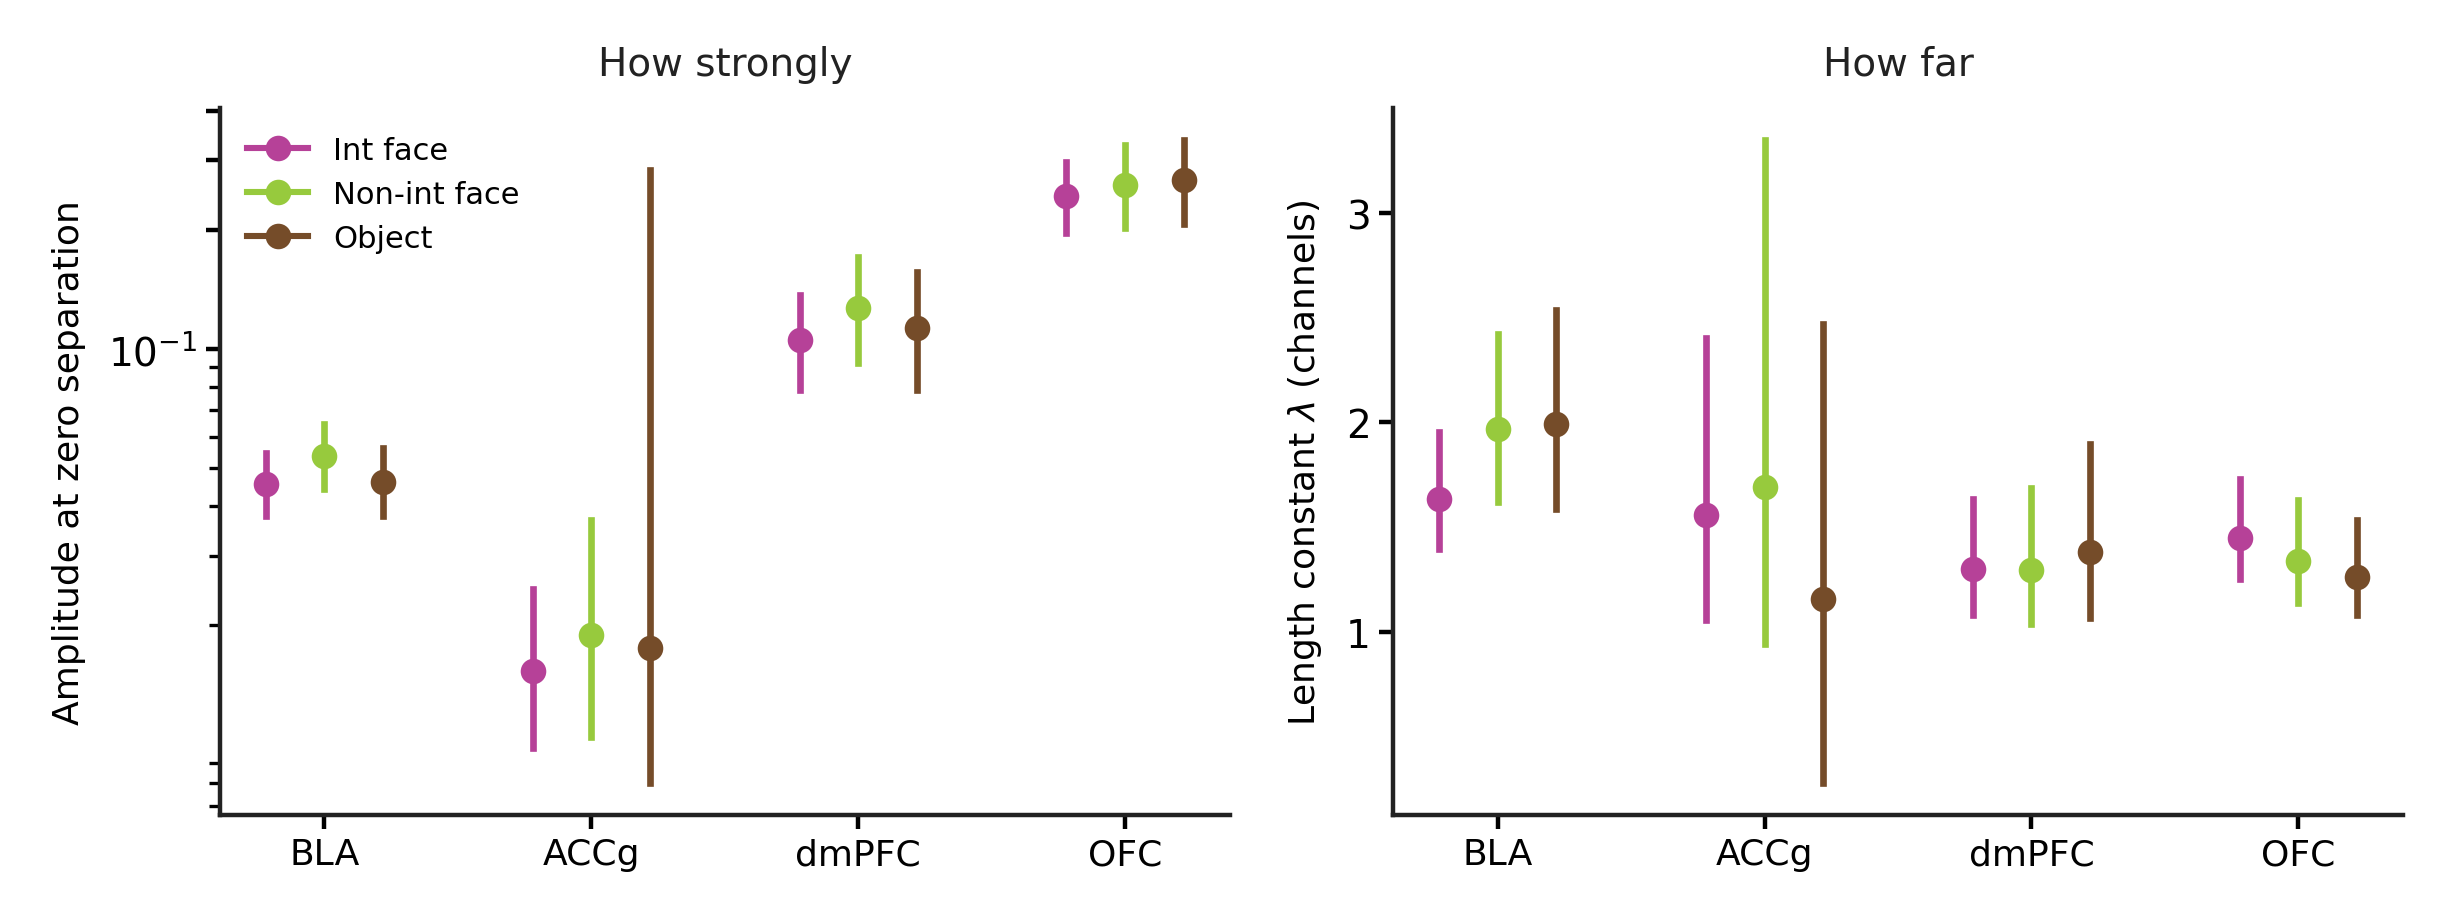

In [8]:
decay_by_condition = sd.build_decay_table(pairs, settings, by_condition=True)
fits_by_condition = sd.fit_decay_by_group(
    decay_by_condition, group_columns=("region", "condition")
)
display(fits_by_condition.round(4))

fig, paths = viz.plot_decay_by_condition(decay_by_condition, fits_by_condition, figs)
display(Image(filename=str(paths["png"])))

fig, paths = viz.plot_fit_parameters(fits_by_condition, figs, by_condition=True)
display(Image(filename=str(paths["png"])))

### Does the condition difference track separation?

A third possibility: the conditions might differ only at short range, where
coordination is strong, and converge at long range. This computes the
within-pair condition difference *inside* each separation bin, so such a trend
would show up across bins.

Trial-count matched, because interactive-face fixations outnumber the others
roughly six to one and an unmatched comparison mostly reflects that. Effect
sizes rather than means: at these sample sizes a mean difference of a few
ten-thousandths reaches significance and says nothing.

,region,separation_bin,separation,n_pairs,mean_difference,effect_size_rank_biserial,p_value,p_value_corrected,significant
0,bla,1,1.0,3989,-0.00033,-0.00326,0.93344,0.99527,False
1,bla,2–3,2.5,6827,-0.00004,0.00441,0.99527,0.99527,False
2,bla,4–7,5.5,9861,0.00052,0.02106,0.03305,0.06977,False
3,bla,8–15,11.5,6313,0.00243,0.02686,0.01650,0.05225,False
4,accg,1,1.0,1039,-0.00368,0.01444,0.77718,0.92290,False
5,accg,2–3,2.5,1781,-0.00468,0.01067,0.94749,0.99527,False
6,accg,4–7,5.5,2678,-0.00780,-0.01046,0.03280,0.06977,False
7,accg,8–15,11.5,2962,-0.00948,0.01486,0.30532,0.44624,False
8,accg,>15,24.0,3163,-0.01169,0.03289,0.08688,0.15007,False
9,dmpfc,1,1.0,1074,0.00426,0.06145,0.01642,0.05225,False


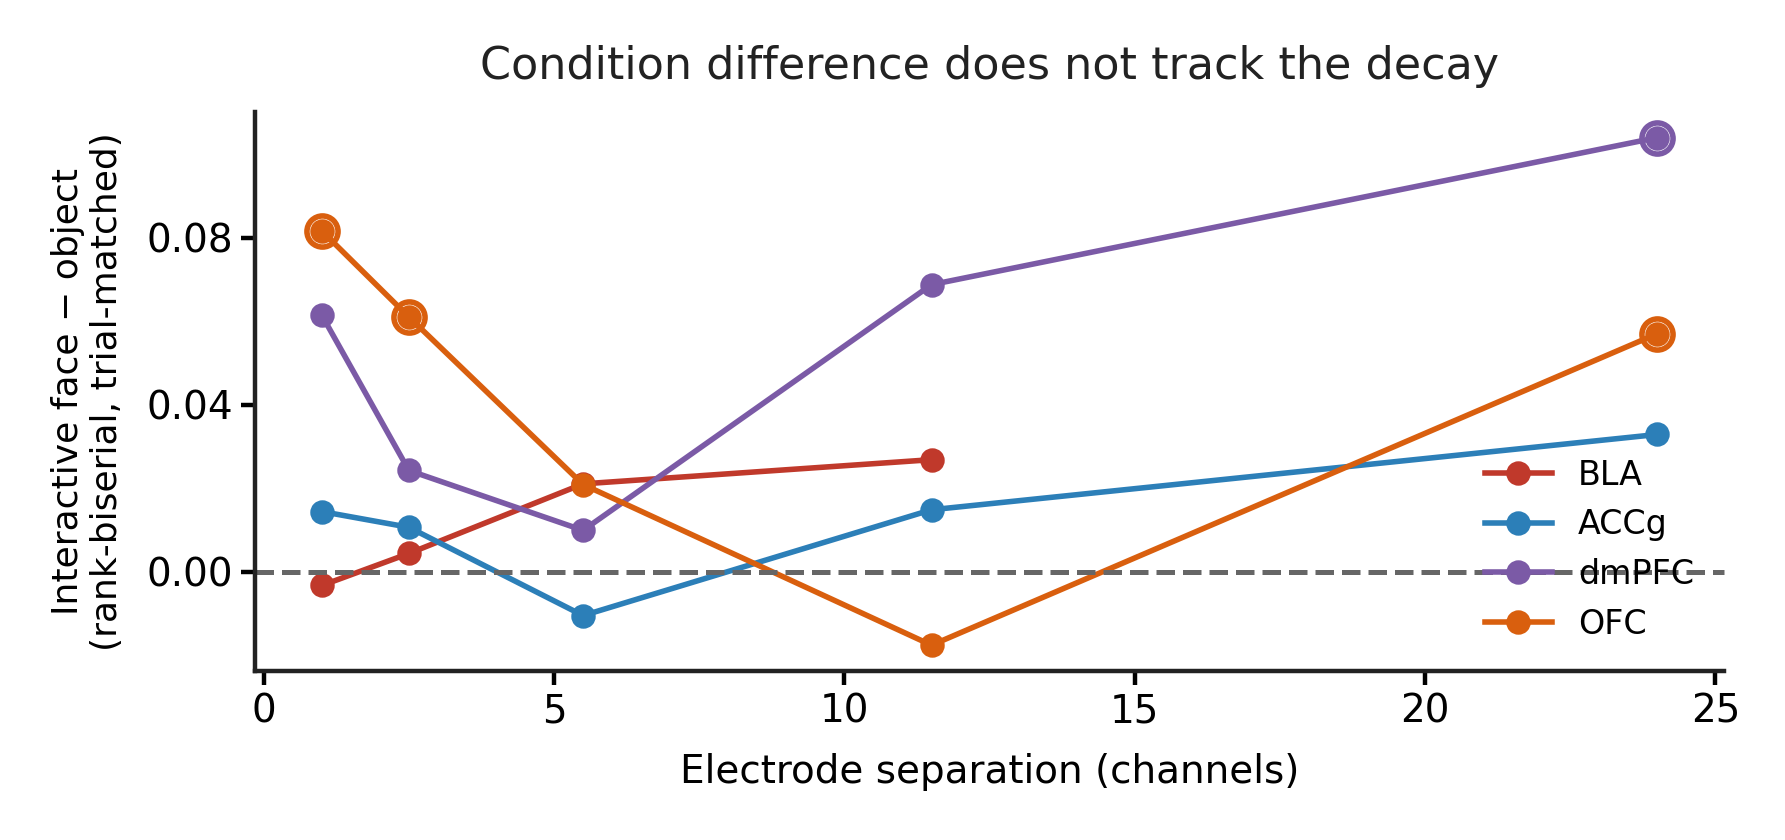

4 of 19 region x separation cells reach significance, max |effect size| = 0.104


In [9]:
trend = sd.test_condition_by_separation(pairs)
display(trend.round(5))

fig, paths = viz.plot_condition_by_separation(trend, figs)
display(Image(filename=str(paths["png"])))

n_sig = int(trend["significant"].sum())
print(f"{n_sig} of {len(trend)} region x separation cells reach significance, "
      f"max |effect size| = {trend['effect_size_rank_biserial'].abs().max():.3f}")

## 4. Does the broad shoulder decay too?

The sharp peak and the broad shoulder could have different spatial extents —
millisecond synchrony and slower co-fluctuation need not travel the same
distance. If the shoulder decays with a similar length constant, the two are
plausibly the same underlying local structure seen at two timescales.

,region,amplitude,amplitude_low,amplitude_high,length_constant,length_constant_low,length_constant_high,offset,r_squared,n_bins,total_pairs
0,bla,0.0037,0.0033,0.0041,2.9668,2.3456,3.7709,0.0017,0.9999,4.0,101473
1,accg,0.0018,0.0016,0.0021,6.0908,4.5011,8.3256,0.0000,0.9770,5.0,41758
2,dmpfc,0.0103,0.0087,0.0121,2.9239,2.3728,3.6018,0.0023,0.9798,5.0,34426
3,ofc,0.0222,0.0209,0.0236,5.0438,4.3058,5.8101,0.0009,0.9807,5.0,55057


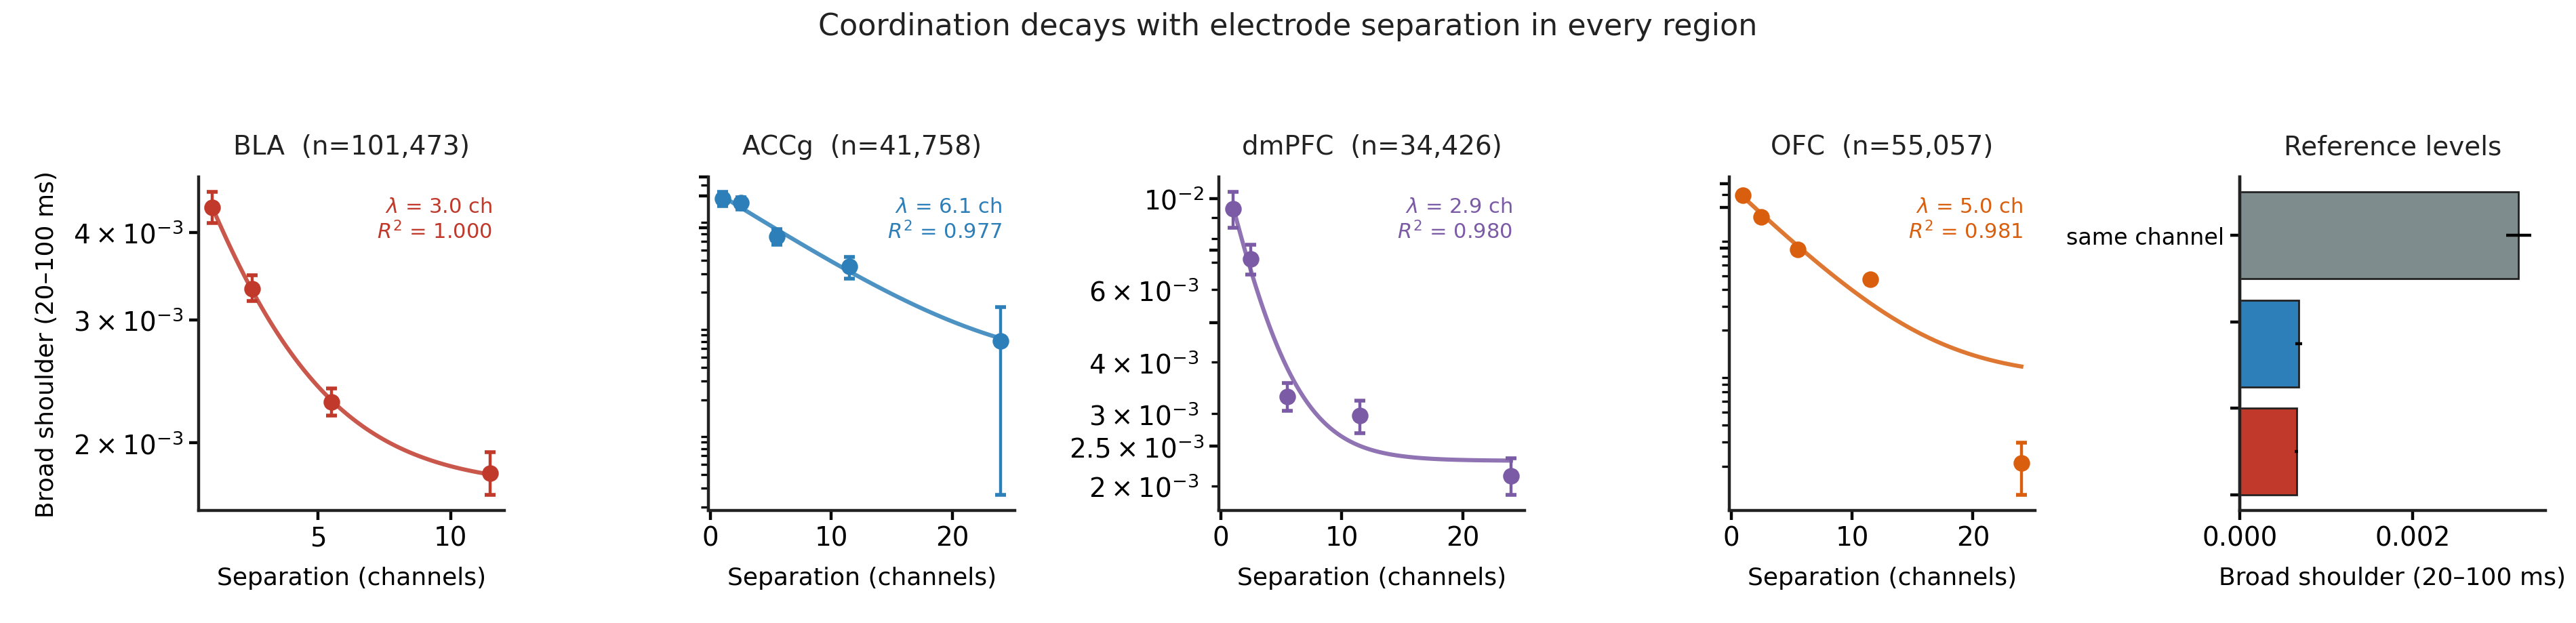

In [10]:
shoulder = sd.build_decay_table(pairs, settings, metric=sd.SHOULDER_METRIC)
shoulder_fits = sd.fit_decay_by_group(shoulder)
display(shoulder_fits.round(4))

fig, paths = viz.plot_decay_curves(
    shoulder, shoulder_fits, figs,
    references=sd.build_reference_levels(pairs, metric=sd.SHOULDER_METRIC),
    metric=sd.SHOULDER_METRIC, stem="fig07_decay_curves_shoulder",
)
display(Image(filename=str(paths["png"])))

## 5. Does the selective subset behave differently?

Restricting to pairs where **both** units are FDR-selective for at least one
fixation-condition contrast. Selecting units by a condition contrast and then
asking about condition effects would be circular, but that is not what is asked
here — the question is whether the *spatial architecture* looks different in the
selective subpopulation, which selection on condition does not predetermine.

In [11]:
selective_settings = sd.SpatialDecaySettings(
    cfg_path=settings.cfg_path, selective_only=True
)
selective_pairs, _ = sd.load_pairs_with_separation(selective_settings)
print(f"pairs with both units FDR-selective: {len(selective_pairs):,}")

selective_decay = sd.build_decay_table(selective_pairs, selective_settings)
selective_fits = sd.fit_decay_by_group(selective_decay)
display(selective_fits.round(4))

comparison = fits.merge(selective_fits, on="region", suffixes=("_all", "_selective"))
display(
    comparison.loc[
        :, ["region", "amplitude_all", "amplitude_selective",
            "length_constant_all", "length_constant_selective"]
    ].round(4)
)

pairs with both units FDR-selective: 116,132


,region,amplitude,amplitude_low,amplitude_high,length_constant,length_constant_low,length_constant_high,offset,r_squared,n_bins,total_pairs
0,bla,0.0251,0.0205,0.0308,2.2251,1.6973,3.0107,0.0073,0.9996,4.0,37990
1,accg,0.0169,0.0070,0.0386,1.3073,0.7256,2.3738,0.0034,0.9368,5.0,6799
2,dmpfc,0.0781,0.0619,0.1011,2.2951,1.6704,3.1329,0.0055,0.9890,5.0,6719
3,ofc,0.2973,0.2372,0.3676,1.4760,1.2492,1.8059,0.0121,0.9832,5.0,13472


,region,amplitude_all,amplitude_selective,length_constant_all,length_constant_selective
0,bla,0.0478,0.0251,1.8463,2.2251
1,accg,0.0168,0.0169,1.4922,1.3073
2,dmpfc,0.1143,0.0781,1.3201,2.2951
3,ofc,0.2554,0.2973,1.3508,1.4760


## What to take from this

Fill in against the numbers above:

- **The decay is real, not an array offset.** Coordination falls monotonically
  with electrode separation in every region, which a shared reference cannot
  produce.
- **Regions differ in amplitude, not in reach.** Compare the two panels of the
  fit-parameter figure.
- **The architecture does not depend on the fixation condition.** Compare the
  bootstrap intervals across conditions in section 3.

### Caveats worth carrying into any write-up

1. Channel separation is an uncalibrated proxy for distance.
2. BLA has no pairs beyond 15 channels apart, so its long-range offset is the
   least constrained of the four fits.
3. The far within-region level sits somewhat above the cross-region level; some
   same-array offset may remain even after the decay is accounted for.
4. ACCg is the shallowest decay and also the region with the narrowest
   correlation peak — worth scrutiny, since "spatially flat and millisecond
   wide" is also what a residual common-noise contribution would look like.